# 3. Data Preparation 🌱 Crops Yield & Price Forecast | Manuel Lombardi


### 3.1 Carga de datos


In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/df.csv', dtype={'departamento_id': 'string'})
df_climas = pd.read_csv('../data/processed/df_clima_filtrado.csv', dtype={'Departamento_id': 'string'})
df_ventanas = pd.read_csv('../data/raw/ventanas_fenologicas.csv', encoding='utf-8-sig')

with open('../data/raw/departamentos_boxes.geojson', 'r', encoding='utf-8') as f:
    deptos_gj = json.load(f)
ids_158 = [feat['properties']['id'] for feat in deptos_gj['features']]

mapa_zona = pd.read_csv('../src/mapa_departamento_zona.csv', dtype={'departamento_id': 'string'})
zona_mani = pd.read_csv('../src/zona_mani_por_departamento.csv', dtype={'departamento_id': 'string'})

ndvi_dir = '../data/raw/ndvi_departamentos/'
archivos_ndvi_dir = sorted(os.listdir(ndvi_dir))
archivos_ndvi_mean = [a for a in archivos_ndvi_dir if 'pixel_reliability' not in a]
archivos_reliability = [a for a in archivos_ndvi_dir if 'pixel_reliability' in a]

dfs_ndvi = [pd.read_csv(f'{ndvi_dir}{archivo}') for archivo in archivos_ndvi_mean]
df_ndvi = pd.concat(dfs_ndvi, ignore_index=True)

dfs_reliability = [pd.read_csv(f'{ndvi_dir}{archivo}') for archivo in archivos_reliability]
df_reliability = pd.concat(dfs_reliability, ignore_index=True)

df_precios_girasol = pd.read_csv('../data/processed/precios_girasol_usd.csv')
df_precios_maiz = pd.read_csv('../data/processed/precios_maiz_usd.csv')
df_precios_soja = pd.read_csv('../data/processed/precios_soja_usd.csv')
df_precios_trigo = pd.read_csv('../data/processed/precios_trigo_usd.csv')

print(f"df (campañas): {df.shape} | df_climas: {df_climas.shape} | df_ventanas: {df_ventanas.shape}")
print(f"departamentos en departamentos_boxes.geojson: {len(ids_158)}")
print(f"df_ndvi ({len(archivos_ndvi_mean)} archivos, capa NDVI): {df_ndvi.shape}")
print(f"df_reliability ({len(archivos_reliability)} archivos, capa pixel_reliability): {df_reliability.shape}")


df (campañas): (29885, 14) | df_climas: (1538144, 10) | df_ventanas: (126, 7)
departamentos en departamentos_boxes.geojson: 158
df_ndvi (27 archivos, capa NDVI): (100488, 16)
df_reliability (27 archivos, capa pixel_reliability): (100488, 6)


En esta sección cargamos los datasets ya preparados a nivel departamento en el notebook 02 (`df.csv`, `df_clima_filtrado.csv`), más los insumos geográficos y de mapeo necesarios para pasar de 15 zonas PAS a 158 departamentos: el geojson de departamentos, el mapeo departamento → zona PAS (`mapa_departamento_zona.csv`) y el mapeo departamento → zona Maní (`zona_mani_por_departamento.csv`, ver 3.2.5).

> ✅ Los archivos de NDVI departamental incluyen ahora las 54 capas completas de AppEEARS (27 `_250m_16_days_NDVI` + 27 `_250m_16_days_pixel_reliability`, una por año 2000–2026). La capa `pixel_reliability` se usa en la sección 3.2.9 como **diagnóstico de calidad** (% de píxeles buenos/marginales/nublados por departamento y fecha), igual que en el pipeline anterior de 15 zonas — **no se usa como filtro** que cambie el dataset de entrenamiento. Esa decisión ya estaba tomada de antes y no se reabre acá; `calcular_features_ndvi` (3.2.8) sigue promediando `Mean` sin filtrar por confiabilidad de píxel.


### 3.2 Track B — Rendimiento


Comenzamos a preparar el dataset que luego será usado para entrenar el modelo de rendimiento. A diferencia del pipeline anterior (15 zonas PAS, cajas rectangulares aproximadas sobre la Bolsa de Cereales de Buenos Aires), ahora trabajamos a nivel de 158 departamentos reales (polígonos oficiales de georef-ar), con 6 cultivos: Girasol, Maíz, Maní, Soja 1ra, Soja 2da y Trigo total — Soja 1ra y Soja 2da se tratan como cultivos distintos en toda esta sección, nunca combinados.


#### 3.2.1 Limpieza final del dataset de campañas


In [2]:
print(df.head())
print("============================================")
print("Tamaño del dataframe:", df.shape)


   cultivo  anio   campania     provincia  provincia_id     departamento  \
0  girasol  2000  2000/2001  Buenos Aires             6             Azul   
1  girasol  2000  2000/2001  Buenos Aires             6     Bahía Blanca   
2  girasol  2000  2000/2001  Buenos Aires             6     San Cayetano   
3  girasol  2000  2000/2001  Buenos Aires             6      San Nicolás   
4  girasol  2000  2000/2001  Buenos Aires             6  Trenque Lauquen   

  departamento_id  superficie_sembrada_ha  superficie_cosechada_ha  \
0           06049                   16000                    15500   
1           06056                    3000                      400   
2           06742                   50500                    49500   
3           06763                     200                      200   
4           06826                   21000                    19000   

   produccion_tm  rendimiento_kgxha  superficie_perdida_ha departamento_clima  \
0          25500               1645      

Observamos los registros del DataFrame de campañas ya filtrado por cultivo y campaña (≥ 2000/2001) en el notebook 02, todavía a nivel de los 347 departamentos que reportan alguno de estos 6 cultivos.


In [3]:
df = df[(df['superficie_sembrada_ha'] > 0) & (df['superficie_cosechada_ha'] > 0)]
print(df.head())
print("============================================")
print("Tamaño del dataframe después del filtrado:", df.shape)
print("Departamentos únicos:", df['departamento_id'].nunique())


   cultivo  anio   campania     provincia  provincia_id     departamento  \
0  girasol  2000  2000/2001  Buenos Aires             6             Azul   
1  girasol  2000  2000/2001  Buenos Aires             6     Bahía Blanca   
2  girasol  2000  2000/2001  Buenos Aires             6     San Cayetano   
3  girasol  2000  2000/2001  Buenos Aires             6      San Nicolás   
4  girasol  2000  2000/2001  Buenos Aires             6  Trenque Lauquen   

  departamento_id  superficie_sembrada_ha  superficie_cosechada_ha  \
0           06049                   16000                    15500   
1           06056                    3000                      400   
2           06742                   50500                    49500   
3           06763                     200                      200   
4           06826                   21000                    19000   

   produccion_tm  rendimiento_kgxha  superficie_perdida_ha departamento_clima  \
0          25500               1645      

Filtramos los registros donde no se sembró o no se cosechó, igual que en el pipeline anterior. A diferencia de ese pipeline, ya no filtramos una zona `'Otras'`: esa zona era un cajón de sastre de la zonificación PAS de 15 zonas (Corrientes/Misiones, sin mucho movimiento de mercado), y ninguno de los 158 departamentos que vamos a usar mapea a `'Otras'` (ver 3.2.5) — el filtro geográfico de la sección 3.2.2 cumple un rol equivalente, de forma más precisa.


#### 3.2.2 Filtro de departamentos por cobertura de superficie sembrada


El archivo de estimaciones agrícolas trae **347 departamentos** distintos que reportan superficie de alguno de los 6 cultivos analizados desde 2000 (sobre 507 departamentos en el archivo completo, considerando todos los cultivos, no sólo estos 6). Descargar clima diario (NASA POWER) y NDVI (MODIS) para los 347 no es viable en tiempo/costo, así que el proyecto trabaja con un subconjunto: `departamentos_boxes.geojson` trae los **158 departamentos** que concentran la mayor superficie sembrada acumulada (2000–2024) de estos 6 cultivos, y son los únicos para los que efectivamente se descargó clima (`clima_departamentos/`) y NDVI (`ndvi_departamentos/`).

A continuación se reconstruye la curva de cobertura acumulada para verificar qué porcentaje de la superficie sembrada nacional (de estos 6 cultivos) cubren realmente esos 158 departamentos — no se toma el número de memoria, se recalcula sobre este dataset.


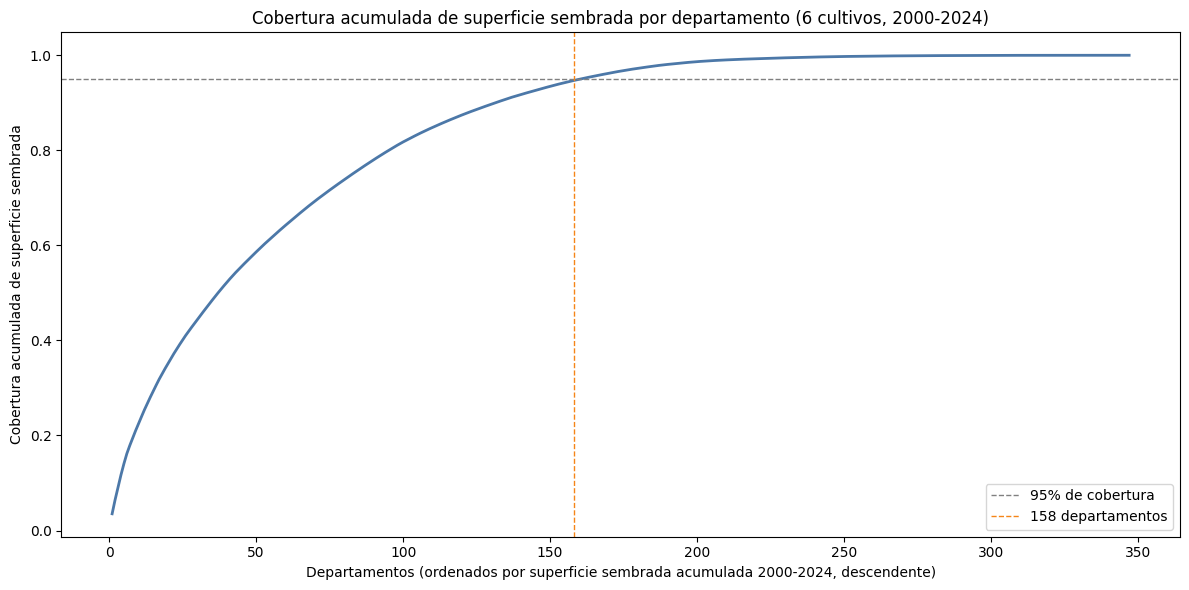

Departamentos con siembra registrada: 347
Cobertura acumulada de los 158 departamentos de departamentos_boxes.geojson: 94.2%


In [4]:
sup_por_depto = df.groupby('departamento_id')['superficie_sembrada_ha'].sum().sort_values(ascending=False)
cobertura_acumulada = sup_por_depto.cumsum() / sup_por_depto.sum()
cobertura_158 = sup_por_depto.reindex(ids_158).fillna(0).sum() / sup_por_depto.sum()

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cobertura_acumulada) + 1), cobertura_acumulada.values, color='#4C78A8', linewidth=2)
plt.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='95% de cobertura')
plt.axvline(158, color='#F58518', linestyle='--', linewidth=1, label='158 departamentos')
plt.xlabel('Departamentos (ordenados por superficie sembrada acumulada 2000-2024, descendente)')
plt.ylabel('Cobertura acumulada de superficie sembrada')
plt.title('Cobertura acumulada de superficie sembrada por departamento (6 cultivos, 2000-2024)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Departamentos con siembra registrada: {len(sup_por_depto)}")
print(f"Cobertura acumulada de los 158 departamentos de departamentos_boxes.geojson: {cobertura_158:.1%}")


Los 158 departamentos de `departamentos_boxes.geojson` cubren **94,2%** de la superficie sembrada nacional de estos 6 cultivos en 2000–2024 (verificado directamente sobre este dataset) — cercano al ~95% mencionado como criterio de selección; la pequeña diferencia probablemente responde a un rango de años o a un criterio de ranking (ej. superficie cosechada en vez de sembrada, o promedio de campaña en vez de acumulado histórico) levemente distinto al usado para construir el geojson, que no viene documentado en el archivo en sí. No se recalcula el conjunto de 158 a partir de este ranking propio — se usa tal cual viene `departamentos_boxes.geojson`, porque es el que tiene clima y NDVI efectivamente descargados; recalcularlo dejaría departamentos sin esos datos.


In [5]:
df = df[df['departamento_id'].isin(ids_158)].copy()
print("Filas tras el filtro de 158 departamentos:", len(df))
print("Departamentos únicos tras el filtro:", df['departamento_id'].nunique())


Filas tras el filtro de 158 departamentos: 18958
Departamentos únicos tras el filtro: 157


Quedan **157** departamentos con registros, no 158: uno de los 158 con clima/NDVI descargado no tiene superficie sembrada positiva de ninguno de los 6 cultivos en el período analizado. No es un problema para el resto del pipeline — simplemente ese departamento no aporta filas de campañas (aunque sí tiene datos climáticos, sin uso en este dataset).


#### 3.2.3 Conversión de unidades y renombre de columnas


El archivo de estimaciones trae el rendimiento en **kg/Ha** (`rendimiento_kgxha`), no en quintales por hectárea (qq/Ha) como el pipeline anterior de 15 zonas. Convertimos explícitamente (1 quintal = 100 kg) y renombramos las columnas al esquema que ya usa el resto del código (`calcular_metricas`, `entrenar_con_kfold` en notebook 05, que referencian estas columnas por nombre exacto):

| Columna original | Columna final |
|---|---|
| `cultivo` / `departamento` / `departamento_id` / `campania` / `anio` | `Cultivo` / `Departamento` / `Departamento_id` / `Campaña` / `Anio_Inicio` |
| `superficie_sembrada_ha` | `Sembrado(Ha)` |
| `superficie_cosechada_ha` | `Cosechado(Ha)` |
| `superficie_perdida_ha` (ya derivada en notebook 02 como sembrada − cosechada) | `Perdido(Ha)` |
| `produccion_tm` | `Producción(MTn)` |
| `rendimiento_kgxha` ÷ 100 | `Rinde(qq/Ha)` |

A diferencia del dataset de 15 zonas (que traía `Sembrado`, `Perdido` y `Cosechado` como tres columnas reportadas de forma independiente por la fuente), acá `Perdido(Ha)` es una columna **derivada** (`Sembrado − Cosechado`), no reportada de forma independiente — el chequeo de sanidad `Sembrado = Perdido + Cosechado` es entonces una identidad algebraica, no una validación cruzada real (ver notebook 02, sección 2.3). Se mantiene la columna de todos modos porque el notebook 05 la excluye por nombre exacto de la lista de features (fuga de información: junto con `Sembrado(Ha)` determina `Cosechado(Ha)` de forma determinística).

También descartamos acá `departamento_clima` y `anio_inicio`, dos columnas que quedaron pegadas a `df.csv` como subproducto de la exploración del notebook 02 y no aportan nada sobre `Departamento`/`Anio_Inicio`.


In [6]:
df = df.rename(columns={
    'cultivo': 'Cultivo',
    'departamento': 'Departamento',
    'departamento_id': 'Departamento_id',
    'campania': 'Campaña',
    'anio': 'Anio_Inicio',
    'superficie_sembrada_ha': 'Sembrado(Ha)',
    'superficie_cosechada_ha': 'Cosechado(Ha)',
    'superficie_perdida_ha': 'Perdido(Ha)',
    'produccion_tm': 'Producción(MTn)',
})
df['Rinde(qq/Ha)'] = df['rendimiento_kgxha'] / 100
df = df.drop(columns=['rendimiento_kgxha', 'provincia', 'provincia_id', 'departamento_clima', 'anio_inicio'], errors='ignore')

condicion = (df['Sembrado(Ha)'] - df['Perdido(Ha)']) == df['Cosechado(Ha)']
print(f"Identidad Sembrado = Perdido + Cosechado se cumple en: {condicion.mean():.2%} de los registros (esperado: 100%, ver arriba)")

df.head()


Identidad Sembrado = Perdido + Cosechado se cumple en: 100.00% de los registros (esperado: 100%, ver arriba)


,Cultivo,Anio_Inicio,Campaña,Departamento,Departamento_id,Sembrado(Ha),Cosechado(Ha),Producción(MTn),Perdido(Ha),Rinde(qq/Ha)
0,girasol,2000,2000/2001,Azul,06049,16000,15500,25500,500,16.45
2,girasol,2000,2000/2001,San Cayetano,06742,50500,49500,54450,1000,11.00
4,girasol,2000,2000/2001,Trenque Lauquen,06826,21000,19000,42000,2000,22.11
5,girasol,2000,2000/2001,San Pedro,06770,800,800,1760,0,22.00
6,girasol,2000,2000/2001,Salliqueló,06721,11300,11225,18500,75,16.48


#### 3.2.4 Restricción de Maní al cinturón núcleo


Maní se reporta en 62 de los 158 departamentos filtrados, pero las ventanas fenológicas de Maní (`ventanas_fenologicas.csv`) sólo existen para las 3 zonas del cinturón manisero núcleo (Maní Oeste/Núcleo/Este — 10 departamentos de Córdoba, ver 3.2.5). Esos 10 departamentos concentran 84,3% de la superficie sembrada de Maní dentro de los 158 (verificado sobre este dataset); los otros 52 son productores marginales y dispersos, para los que no existe (ni tendría sentido extrapolar) una ventana fenológica propia.

Se restringe el análisis de Maní a esos 10 departamentos: las filas de Maní de los otros 52 se descartan acá, antes del join climático, en vez de dejar que se conviertan en NaN silencioso más adelante.


In [7]:
belt_ids = set(zona_mani['departamento_id'])
filas_mani_antes = (df['Cultivo'] == 'maní').sum()
df = df[(df['Cultivo'] != 'maní') | (df['Departamento_id'].isin(belt_ids))].copy()
filas_mani_despues = (df['Cultivo'] == 'maní').sum()
print(f"Filas de Maní antes del recorte al cinturón núcleo: {filas_mani_antes}")
print(f"Filas de Maní después del recorte: {filas_mani_despues}")
print(f"Tamaño final del dataframe de campañas: {df.shape}")


Filas de Maní antes del recorte al cinturón núcleo: 634
Filas de Maní después del recorte: 213
Tamaño final del dataframe de campañas: (18537, 10)


#### 3.2.5 Definición de ventanas fenológicas


In [8]:
df_ventanas[df_ventanas['cultivo'] == 'Trigo']


,cultivo,zona,etapa,mes_inicio,dia_inicio,mes_fin,dia_fin
4,Trigo,Núcleo Norte,floracion,9,15,10,15
5,Trigo,Núcleo Norte,llenado,10,16,11,30
12,Trigo,Núcleo Sur,floracion,9,15,10,15
13,Trigo,Núcleo Sur,llenado,10,16,11,30
20,Trigo,Centro N Cba,floracion,9,15,10,15
21,Trigo,Centro N Cba,llenado,10,16,11,30
28,Trigo,Centro N Sta Fe,floracion,9,15,10,15
29,Trigo,Centro N Sta Fe,llenado,10,16,11,30
36,Trigo,S Cba,floracion,9,15,10,15
37,Trigo,S Cba,llenado,10,16,11,30


Las ventanas fenológicas son los periodos cortos y específicos del ciclo de vida de un cultivo en los que la planta atraviesa una etapa de cambio fisiológico clave, como la floración o el llenado de grano. En estos momentos precisos, la planta es extremadamente sensible a su entorno y define su rendimiento final.
**Por qué son importantes**
- Guían el trabajo: indican el momento exacto para aplicar riegos, abonos o defensas contra plagas.
- Evitan pérdidas: actuar fuera de esa ventana puede dañar la flor, reducir la cosecha o desperdiciar productos costosos.
- Mejoran la eficiencia: la planta asimila mejor los nutrientes cuando el estímulo coincide con su necesidad biológica real.


Los valores provienen de una entrevista realizada a un ingeniero agrónomo.


#### 3.2.6 Mapeo departamento → zona (depende del cultivo)


A diferencia del dataset de 15 zonas (donde cada registro ya traía su `Zona` directamente), acá hay que resolver la zona a partir de `Departamento_id` — y **la zona depende del cultivo**, no sólo del departamento:

- Para los 5 cultivos "no-Maní" (Girasol, Maíz, Soja 1ra, Soja 2da, Trigo total), la zona es la zona PAS heredada del departamento, en `mapa_departamento_zona.csv` (`src/mapa_depto_zona.py`): a cada uno de los 158 departamentos se le asignó la zona PAS de `zonas_bounding_boxes.csv` cuyo rectángulo contiene al centroide del departamento. De los 158: **99** tuvieron un único rectángulo candidato (`match_unico`), **46** cayeron en más de un rectángulo superpuesto y se resolvieron por distancia del centroide al centro de cada zona (`desempate_por_distancia`), y **13** no cayeron dentro de ningún rectángulo y también se resolvieron por distancia al centro más cercano (`0_candidatas`).
- Para Maní, la zona es una de las 3 zonas del cinturón núcleo (Maní Oeste/Núcleo/Este), en `zona_mani_por_departamento.csv` — sólo definida para los 10 departamentos del cinturón (ver 3.2.4), asignada por terciles de longitud del centroide (4 departamentos en Oeste, 3 en Núcleo, 3 en Este; `src/mapa_mani_zona.py`).

Estos dos mapeos son mutuamente excluyentes por cultivo: el join contra `ventanas_fenologicas.csv` tiene que hacerse por `(Departamento_id, Cultivo) → Zona`, no por `Departamento_id` solo. Si el cálculo de features climáticas/NDVI asumiera una única zona fija por departamento (ignorando el cultivo), un departamento del cinturón manisero que también siembra soja o maíz recibiría por error la ventana fenológica de Maní para esos otros cultivos — un error silencioso, porque el merge no daría NaN, daría fechas equivocadas.


In [9]:
cultivo_a_ventana = {
    'girasol': 'Girasol', 'maíz': 'Maíz', 'maní': 'Maní',
    'soja 1ra': 'Soja', 'soja 2da': 'Soja', 'trigo total': 'Trigo',
}
df['cultivo_ventana'] = df['Cultivo'].map(cultivo_a_ventana)
assert df['cultivo_ventana'].notna().all(), "hay cultivos sin mapeo a ventana fenológica"

mapa_zona_dict = mapa_zona.set_index('departamento_id')['zona_pas'].to_dict()
zona_mani_dict = zona_mani.set_index('departamento_id')['zona_mani'].to_dict()

def resolver_zona(departamento_id, cultivo):
    if cultivo == 'maní':
        return zona_mani_dict.get(departamento_id)
    return mapa_zona_dict.get(departamento_id)

df['Zona'] = [resolver_zona(d, c) for d, c in zip(df['Departamento_id'], df['Cultivo'])]

print("Filas sin zona resuelta:", df['Zona'].isna().sum())
assert df['Zona'].notna().all(), "hay filas sin zona -- no seguir, revisar mapeo"
df[['Cultivo', 'Departamento', 'Departamento_id', 'Zona']].drop_duplicates('Departamento_id').head(10)


Filas sin zona resuelta: 0


,Cultivo,Departamento,Departamento_id,Zona
0,girasol,Azul,06049,Ctro BA
2,girasol,San Cayetano,06742,SE BA
4,girasol,Trenque Lauquen,06826,N LP-O BA
5,girasol,San Pedro,06770,Núcleo Sur
6,girasol,Salliqueló,06721,N LP-O BA
7,girasol,Salto,06714,Núcleo Sur
8,girasol,San Andrés de Giles,06728,Núcleo Sur
9,girasol,Saladillo,06707,Ctro BA
10,girasol,Tres Arroyos,06833,SE BA
12,girasol,Saavedra,06700,SO BA-S LP


Verificamos que las zonas asignadas efectivamente tengan ventana fenológica definida en `ventanas_fenologicas.csv`, y de paso detectamos un problema real en ese archivo: **16 filas duplicadas** (8 combinaciones cultivo×zona×etapa, cada una repetida dos veces con valores idénticos) para la zona `N LP-O BA`. No se pierde información al deduplicar porque los valores son idénticos entre el original y el duplicado — probablemente un error de carga del archivo. El pipeline anterior no lo notaba porque `pivot_table(..., aggfunc='first')` se quedaba silenciosamente con la primera fila de cada duplicado; acá lo deduplicamos de forma explícita antes de seguir, para no depender de ese efecto colateral.


In [10]:
duplicados_ventana = df_ventanas[df_ventanas.duplicated(['cultivo', 'zona', 'etapa'], keep=False)]
print(f"Filas duplicadas en ventanas_fenologicas.csv: {len(duplicados_ventana)}")
print(duplicados_ventana[['cultivo', 'zona', 'etapa']].drop_duplicates().to_string(index=False))

df_ventanas = df_ventanas.drop_duplicates(subset=['cultivo', 'zona', 'etapa']).reset_index(drop=True)

zonas_asignadas = set(df['Zona'].unique())
zonas_en_ventanas = set(df_ventanas['zona'].unique())
print()
print("Zonas asignadas sin ventana fenológica definida:", zonas_asignadas - zonas_en_ventanas)


Filas duplicadas en ventanas_fenologicas.csv: 16
cultivo      zona     etapa
   Soja N LP-O BA floracion
   Soja N LP-O BA   llenado
   Maíz N LP-O BA floracion
   Maíz N LP-O BA   llenado
  Trigo N LP-O BA floracion
  Trigo N LP-O BA   llenado
Girasol N LP-O BA floracion
Girasol N LP-O BA   llenado

Zonas asignadas sin ventana fenológica definida: set()


#### 3.2.7 Feature engineering climático por etapa


> ✅ **Mejora respecto al pipeline anterior:** los datos climáticos de NASA POWER ahora se descargan con el endpoint `/point` sobre el centroide de cada departamento (ver notebook 02, sección 2.1), en vez de promediarse espacialmente sobre la grilla de celdas de una zona PAS entera. La limitación de "variabilidad intra-zonal perdida", documentada en el pipeline de 15 zonas, ya no aplica de la misma forma: cada uno de los 158 departamentos tiene ahora su propia serie climática puntual. Queda como trabajo futuro evaluar la variabilidad *intra-departamental* (un departamento grande todavía puede tener microclimas que el centroide no capture), pero es un problema de escala mucho menor al de zonas que abarcaban varios departamentos.


En esta sección se construyen las features climáticas que el modelo de rendimiento utilizará como input. En vez de usar promedios anuales, las variables se calculan dentro de las ventanas temporales de cada etapa fenológica crítica (floración y llenado de grano), ya que el comportamiento climático durante esas etapas específicas es lo que determina el rendimiento final del cultivo — no el clima del año en general.

Las variables seleccionadas son:

- **Precipitación acumulada:** el agua es el factor limitante principal en sistemas de secano. Su acumulación durante cada etapa determina si el cultivo tuvo el agua necesaria para completar cada proceso fisiológico.
- **Temperatura media:** permite identificar si las condiciones térmicas fueron óptimas o si el cultivo estuvo bajo estrés por calor o frío durante la etapa.
- **Radiación solar promedio:** la fotosíntesis depende directamente de la radiación incidente. Mayor radiación durante el llenado de grano se traduce en mayor acumulación de materia seca.
- **Amplitud térmica:** la diferencia entre temperatura máxima y mínima diaria refleja la variabilidad térmica que el cultivo enfrenta. Alta amplitud puede indicar noches frías que afectan procesos metabólicos nocturnos.
- **Días consecutivos de estrés térmico:** una racha de varios días con temperatura superior al umbral crítico impacta de forma muy distinta a la misma cantidad de días distribuidos a lo largo de la etapa — una racha concentrada no le da tiempo al cultivo a recuperarse entre eventos. Definido para Maíz (T2M_MAX > 32°C), Soja 1ra/2da y Girasol (T2M_MAX > 35°C).
- **Días consecutivos de déficit hídrico:** mismo razonamiento que el estrés térmico — una sequía prolongada sin interrupciones es más dañina que períodos cortos de déficit separados por lluvias.
- **Heladas agronómicas (sólo Trigo en floración):** días con temperatura mínima menor a 2°C durante el espigado pueden destruir la espiga antes de que se formen los granos, siendo el principal riesgo climático para ese cultivo.

> ⚠️ Maní no tiene un umbral de estrés térmico ni de helada agronómica propio definido todavía (recibe 0 en ambas columnas, igual que el resto de los cultivos fuera de su condición). Definir esos umbrales (grados-día, exceso hídrico o helada con suelo seco específicos de maní) requiere información agronómica que todavía no está disponible para este proyecto — queda como trabajo futuro, no se inventan valores.


In [11]:
df_climas['Fecha'] = pd.to_datetime(df_climas['Fecha'])
clima_por_depto = {depto: grupo for depto, grupo in df_climas.groupby('Departamento_id')}
print("Departamentos con clima disponible:", len(clima_por_depto))


def calcular_features_climaticas(df_camp, clima_por_depto, df_ventanas):

    if df_camp is None or clima_por_depto is None or df_ventanas is None:
        raise ValueError("Los parámetros de entrada no pueden ser None")

    resultados = []

    for _, fila in df_camp.iterrows():

        cultivo_ventana = fila['cultivo_ventana']
        zona = fila['Zona']
        depto_id = fila['Departamento_id']
        anio_inicio = fila['Anio_Inicio']
        campania = fila['Campaña']

        ventanas_filtradas = df_ventanas[
            (df_ventanas['cultivo'] == cultivo_ventana) &
            (df_ventanas['zona'] == zona)
        ]

        df_depto = clima_por_depto.get(depto_id)

        for _, ventana in ventanas_filtradas.iterrows():

            # fecha_inicio
            if ventana['mes_inicio'] <= 6:
                anio_inicio_etapa = anio_inicio + 1
            else:
                anio_inicio_etapa = anio_inicio
            fecha_inicio = pd.Timestamp(year=anio_inicio_etapa,
                                        month=ventana['mes_inicio'],
                                        day=ventana['dia_inicio'])

            # fecha_fin
            if ventana['mes_fin'] <= 6:
                anio_fin_etapa = anio_inicio + 1
            else:
                anio_fin_etapa = anio_inicio
            fecha_fin = pd.Timestamp(year=anio_fin_etapa,
                                    month=ventana['mes_fin'],
                                    day=ventana['dia_fin'])

            if df_depto is None:
                precipitacion_total = temperatura_media = radiacion_solar_promedio = np.nan
                amplitud_termica = deficit_hidrico_extremo = np.nan
                estres_termico = helada_agro = np.nan
            else:
                df_filtrado = df_depto[
                    (df_depto['Fecha'] >= fecha_inicio) &
                    (df_depto['Fecha'] <= fecha_fin)
                ]

                precipitacion_total = df_filtrado['PRECTOTCORR'].sum()
                temperatura_media = df_filtrado['T2M'].mean()
                radiacion_solar_promedio = df_filtrado['ALLSKY_SFC_SW_DWN'].mean()
                amplitud_termica = (df_filtrado['T2M_MAX'] - df_filtrado['T2M_MIN']).mean()

                condicion = df_filtrado['PRECTOTCORR'] < 1
                grupos = (~condicion).cumsum()
                rachas = condicion.groupby(grupos).sum()
                deficit_hidrico_extremo = rachas.max() if len(rachas) > 0 else 0

                estres_termico = 0
                helada_agro = 0
                cultivo = fila['Cultivo']

                if cultivo == 'maíz':
                    condicion = df_filtrado['T2M_MAX'] > 32
                    grupos = (~condicion).cumsum()
                    rachas = condicion.groupby(grupos).sum()
                    estres_termico = rachas.max() if len(rachas) > 0 else 0
                elif cultivo in ('soja 1ra', 'soja 2da', 'girasol'):
                    condicion = df_filtrado['T2M_MAX'] > 35
                    grupos = (~condicion).cumsum()
                    rachas = condicion.groupby(grupos).sum()
                    estres_termico = rachas.max() if len(rachas) > 0 else 0
                elif cultivo == 'trigo total':
                    if ventana['etapa'] == 'floracion':
                        condicion = df_filtrado['T2M_MIN'] <= 2
                        grupos = (~condicion).cumsum()
                        rachas = condicion.groupby(grupos).sum()
                        helada_agro = rachas.max() if len(rachas) > 0 else 0

            calculos = {
                'Cultivo': fila['Cultivo'],
                'Departamento_id': depto_id,
                'Campaña': campania,
                'Etapa': ventana['etapa'],
                'Fecha_Inicio': fecha_inicio,
                'Fecha_Fin': fecha_fin,
                'precipitacion_total': precipitacion_total,
                'deficit_hidrico_extremo': deficit_hidrico_extremo,
                'temperatura_media': temperatura_media,
                'radiacion_solar_promedio': radiacion_solar_promedio,
                'amplitud_termica': amplitud_termica,
                'estres_termico': estres_termico,
                'helada_agro': helada_agro
            }

            resultados.append(calculos)

    return resultados


Departamentos con clima disponible: 158


In [12]:
resultados = calcular_features_climaticas(df, clima_por_depto, df_ventanas)
df_resultados = pd.DataFrame(resultados)
print(df_resultados.shape)
print(df_resultados.isna().sum())
df_resultados.head()


(37074, 13)
Cultivo                     0
Departamento_id             0
Campaña                     0
Etapa                       0
Fecha_Inicio                0
Fecha_Fin                   0
precipitacion_total         0
deficit_hidrico_extremo     0
temperatura_media           0
radiacion_solar_promedio    0
amplitud_termica            0
estres_termico              0
helada_agro                 0
dtype: int64


,Cultivo,Departamento_id,Campaña,Etapa,Fecha_Inicio,Fecha_Fin,precipitacion_total,deficit_hidrico_extremo,temperatura_media,radiacion_solar_promedio,amplitud_termica,estres_termico,helada_agro
0,girasol,06049,2000/2001,floracion,2000-12-01,2001-01-15,165.07,7,20.481522,26.802609,17.039130,2,0
1,girasol,06049,2000/2001,llenado,2001-01-16,2001-02-28,151.82,18,23.032273,24.794545,16.741136,2,0
2,girasol,06742,2000/2001,floracion,2000-12-15,2001-01-29,104.66,7,20.585652,25.979130,15.014783,2,0
3,girasol,06742,2000/2001,llenado,2001-01-30,2001-03-14,180.95,17,21.618864,23.526136,14.653409,1,0
4,girasol,06826,2000/2001,floracion,2000-12-15,2001-01-29,134.51,7,23.746304,26.853913,15.464348,6,0


In [13]:
df_resultados_pivot = df_resultados.pivot_table(
    index=['Cultivo', 'Departamento_id', 'Campaña'],
    columns='Etapa',
    values=['precipitacion_total', 'deficit_hidrico_extremo', 'temperatura_media',
            'radiacion_solar_promedio', 'amplitud_termica', 'estres_termico', 'helada_agro'],
    aggfunc='first'
)

df_resultados_pivot.reset_index(inplace=True)

df_resultados_pivot.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in df_resultados_pivot.columns
]

columnas_cero = [
    'estres_termico_floracion',
    'estres_termico_llenado',
    'helada_agro_floracion',
    'helada_agro_llenado',
    'deficit_hidrico_extremo_floracion',
    'deficit_hidrico_extremo_llenado'
]

df_resultados_pivot[columnas_cero] = df_resultados_pivot[columnas_cero].fillna(0)

print("Filas duplicadas de la clave (Cultivo, Departamento_id, Campaña):",
      df_resultados_pivot.duplicated(['Cultivo', 'Departamento_id', 'Campaña']).sum())
df_resultados_pivot.head()


Filas duplicadas de la clave (Cultivo, Departamento_id, Campaña): 0


,Cultivo,Departamento_id,Campaña,amplitud_termica_floracion,amplitud_termica_llenado,deficit_hidrico_extremo_floracion,deficit_hidrico_extremo_llenado,estres_termico_floracion,estres_termico_llenado,helada_agro_floracion,helada_agro_llenado,precipitacion_total_floracion,precipitacion_total_llenado,radiacion_solar_promedio_floracion,radiacion_solar_promedio_llenado,temperatura_media_floracion,temperatura_media_llenado
0,girasol,06007,2000/2001,15.739783,15.060455,7,8,3,4,0,0,79.03,192.48,28.216304,23.179091,24.421087,24.157500
1,girasol,06007,2001/2002,14.397174,15.395909,13,13,1,1,0,0,153.87,53.72,28.650217,23.302955,23.462174,22.493636
2,girasol,06007,2002/2003,15.077826,16.332955,7,9,5,3,0,0,91.53,46.41,28.563696,24.752955,24.269130,24.063864
3,girasol,06007,2003/2004,16.274783,14.545333,12,11,4,1,0,0,108.56,109.24,28.835435,23.225111,25.437391,22.063556
4,girasol,06007,2004/2005,14.755870,13.692273,7,7,2,1,0,0,81.35,77.36,28.752174,22.793864,23.414130,22.884091


#### 3.2.8 Feature engineering NDVI por etapa


El NDVI (Normalized Difference Vegetation Index) mide el vigor de la vegetación a partir de la reflectancia satelital — valores más altos indican mayor biomasa fotosintéticamente activa. MODIS entrega un compuesto cada 16 días; se promedia el valor `Mean` de todas las composiciones que caen dentro de cada ventana fenológica.

A diferencia del pipeline anterior, que mapeaba `aid0001`…`aid0015` a las 15 zonas con un diccionario hardcodeado, acá los archivos traen `aid0001`…`aid0158` — el orden de los `aid` corresponde al orden de las features en `departamentos_boxes.geojson` (documentado por el proyecto), así que el mapeo se genera automáticamente en vez de codificarse a mano.


In [14]:
aid_a_depto = {f"aid{idx+1:04d}": feat['properties']['id'] for idx, feat in enumerate(deptos_gj['features'])}
print("Mapeos aid -> departamento_id:", len(aid_a_depto))

df_ndvi['Departamento_id'] = df_ndvi['aid'].map(aid_a_depto)
assert df_ndvi['Departamento_id'].notna().all(), "hay aid del NDVI sin mapear a un departamento_id"

df_ndvi['fecha_media'] = pd.to_datetime(df_ndvi['Date']) + pd.Timedelta(days=8)
df_ndvi = df_ndvi.rename(columns={'Mean': 'ndvi'})[['Departamento_id', 'fecha_media', 'ndvi']]

df_ndvi.head()


Mapeos aid -> departamento_id: 158


,Departamento_id,fecha_media,ndvi
0,06315,2000-02-26,0.726765
1,06315,2000-03-13,0.730309
2,06315,2000-03-29,0.693895
3,06315,2000-04-14,0.684976
4,06315,2000-04-30,0.663827


In [15]:
def calcular_features_ndvi(df_camp, ndvi_por_depto, df_ventanas):

    if df_camp is None or ndvi_por_depto is None or df_ventanas is None:
        raise ValueError("Los parámetros de entrada no pueden ser None")

    resultados = []

    for _, fila in df_camp.iterrows():

        cultivo_ventana = fila['cultivo_ventana']
        zona = fila['Zona']
        depto_id = fila['Departamento_id']
        anio_inicio = fila['Anio_Inicio']
        campania = fila['Campaña']

        ventanas_filtradas = df_ventanas[
            (df_ventanas['cultivo'] == cultivo_ventana) &
            (df_ventanas['zona'] == zona)
        ]

        df_depto = ndvi_por_depto.get(depto_id)

        for _, ventana in ventanas_filtradas.iterrows():

            # misma lógica de cruce de año que se usa para clima
            if ventana['mes_inicio'] <= 6:
                anio_inicio_etapa = anio_inicio + 1
            else:
                anio_inicio_etapa = anio_inicio
            fecha_inicio = pd.Timestamp(year=anio_inicio_etapa,
                                        month=ventana['mes_inicio'],
                                        day=ventana['dia_inicio'])

            if ventana['mes_fin'] <= 6:
                anio_fin_etapa = anio_inicio + 1
            else:
                anio_fin_etapa = anio_inicio
            fecha_fin = pd.Timestamp(year=anio_fin_etapa,
                                    month=ventana['mes_fin'],
                                    day=ventana['dia_fin'])

            if df_depto is None:
                ndvi_promedio, n_observaciones = np.nan, 0
            else:
                df_filtrado = df_depto[
                    (df_depto['fecha_media'] >= fecha_inicio) &
                    (df_depto['fecha_media'] <= fecha_fin)
                ]
                ndvi_promedio = df_filtrado['ndvi'].mean()
                n_observaciones = len(df_filtrado)

            calculos = {
                'Cultivo': fila['Cultivo'],
                'Departamento_id': depto_id,
                'Campaña': campania,
                'Etapa': ventana['etapa'],
                'ndvi_promedio': ndvi_promedio,
                'ndvi_n_observaciones': n_observaciones,
            }

            resultados.append(calculos)

    return resultados


ndvi_por_depto = {depto: grupo for depto, grupo in df_ndvi.groupby('Departamento_id')}
df_resultados_ndvi = pd.DataFrame(calcular_features_ndvi(df, ndvi_por_depto, df_ventanas))

df_resultados_ndvi_pivot = df_resultados_ndvi.pivot_table(
    index=['Cultivo', 'Departamento_id', 'Campaña'],
    columns='Etapa',
    values=['ndvi_promedio', 'ndvi_n_observaciones'],
    aggfunc='first'
)

df_resultados_ndvi_pivot.reset_index(inplace=True)

df_resultados_ndvi_pivot.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in df_resultados_ndvi_pivot.columns
]

df_resultados_ndvi_pivot.head()


,Cultivo,Departamento_id,Campaña,ndvi_n_observaciones_floracion,ndvi_n_observaciones_llenado,ndvi_promedio_floracion,ndvi_promedio_llenado
0,girasol,06007,2000/2001,4,3,0.391339,0.535827
1,girasol,06007,2001/2002,4,3,0.455765,0.503709
2,girasol,06007,2002/2003,4,3,0.478823,0.453311
3,girasol,06007,2003/2004,4,3,0.399005,0.451509
4,girasol,06007,2004/2005,4,3,0.529024,0.531060


In [16]:
print(df_resultados_ndvi_pivot[['ndvi_promedio_floracion', 'ndvi_promedio_llenado']].isna().sum())
print()
print("Ventanas con 0 observaciones NDVI (floración):", (df_resultados_ndvi_pivot['ndvi_n_observaciones_floracion'] == 0).sum())
print("Ventanas con 0 observaciones NDVI (llenado):", (df_resultados_ndvi_pivot['ndvi_n_observaciones_llenado'] == 0).sum())


ndvi_promedio_floracion    0
ndvi_promedio_llenado      0
dtype: int64

Ventanas con 0 observaciones NDVI (floración): 0
Ventanas con 0 observaciones NDVI (llenado): 0


#### 3.2.9 Feature engineering ONI (índice ENSO) por etapa


El ENSO (El Niño–Southern Oscillation) es el patrón climático interanual con mayor influencia sobre la variabilidad de precipitación y temperatura en la región agrícola argentina — El Niño suele asociarse a campañas más húmedas en el centro-este del país, La Niña a sequías (ver notebook 02, campañas 2008/2009 y 2022/2023). El objetivo de esta sección es agregar el estado de ENSO como feature, para que el modelo pueda distinguir si el clima extremo de una campaña ocurrió *durante* una fase activa de El Niño/La Niña.

**Fuente:** NOAA CPC, [ONI histórico mensual](https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt) (`data/raw/oni.ascii.txt`), serie 1950–presente, columnas `SEAS YR TOTAL ANOM`. Se usa `ANOM` (anomalía de temperatura superficial del océano en la región Niño 3.4 respecto a su climatología de referencia), que es el valor estándar para caracterizar la fase de ENSO.

**Por qué ONI histórico y no RONI:** NOAA CPC mantiene dos versiones del índice. El **ONI histórico** (el que se usa acá) es la serie estable de anomalías desde 1950. El **RONI** (Relative ONI), vigente desde febrero de 2026, resta la tendencia de calentamiento de fondo del océano global antes de calcular la anomalía, y está pensado para el monitoreo operativo de El Niño/La Niña *durante la campaña en curso*. Este proyecto entrena sobre campañas ya cerradas (2000/2001–2024/2025): para entrenar sobre el pasado, el ONI histórico es la elección correcta, porque es la serie con la que esas campañas efectivamente ocurrieron y no se revisa retroactivamente. El RONI pasaría a ser relevante recién si el proyecto se extendiera a *predecir sobre una campaña en curso* (ahí sí importa no confundir una anomalía real con la tendencia de calentamiento de largo plazo) — no es el caso de este dataset de entrenamiento.

**Formato del archivo y mapeo a fecha:** `SEAS` no es un mes calendario, es una ventana móvil de 3 meses superpuestos (`DJF`=Dic-Ene-Feb, `JFM`=Ene-Feb-Mar, `FMA`=Feb-Mar-Abr, …, `NDJ`=Nov-Dic-Ene) — hay una fila por mes, cada una es el promedio centrado en su mes central (ej. `DJF` está centrado en enero). Mapeamos cada código de 3 letras a su mes central; el año (`YR`) que reporta NOAA ya está indexado al año de ese mes central, así que no hace falta ajustarlo. Con eso se arma un diccionario `(año, mes) → ANOM` de granularidad mensual.

**Cálculo por fila:** para cada combinación Cultivo×Departamento×Campaña se toman las mismas fechas de inicio/fin de floración y llenado que ya se usan para las features climáticas (misma lógica de cruce de año, ver 3.2.7), se listan los meses calendario que caen dentro de esa ventana, y se promedia el ONI de esos meses (promedio simple por mes, sin ponderar por días) — el resultado son dos columnas nuevas, `oni_promedio_floracion` y `oni_promedio_llenado`. Deliberadamente no se usa un único ONI de la campaña completa: el objetivo es capturar si El Niño/La Niña estaba activo específicamente durante las etapas críticas del cultivo, no todo el año.

**Versión categórica:** además del valor continuo, se agregan `oni_categoria_floracion` y `oni_categoria_llenado`, discretizando cada promedio con el umbral estándar de NOAA CPC para clasificar la fase de ENSO (±0.5°C de anomalía): `>= 0.5` → `'Niño'`, `<= -0.5` → `'Niña'`, el resto → `'Neutral'`. Las columnas numéricas originales se conservan sin cambios; las categóricas se agregan como columnas nuevas.

**⚠️ Esto NO es un episodio de El Niño/La Niña declarado oficialmente por NOAA.** La definición oficial de NOAA de un *episodio* ENSO exige que el umbral (±0.5°C) se cumpla durante al menos 5 temporadas `SEAS` consecutivas — es un criterio sobre una racha en el tiempo, no sobre un promedio puntual. Acá `oni_categoria_floracion`/`oni_categoria_llenado` categorizan el promedio de ONI *de la ventana de floración o llenado de esa fila específica* (unas semanas, no 5 temporadas), así que una fila puede quedar categorizada como `'Niño'` sin que NOAA haya declarado un episodio de El Niño para esa campaña. Es una simplificación deliberada para reducir la cardinalidad efectiva de la feature de cara al modelo (ver notebook 05, sección 5.9.3) — no un reemplazo del criterio meteorológico oficial, y no debería citarse como tal fuera de este contexto.

In [17]:
seas_a_mes_central = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
    'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12,
}

df_oni = pd.read_csv('../data/raw/oni.ascii.txt', sep=r'\s+')
df_oni['mes_central'] = df_oni['SEAS'].map(seas_a_mes_central)
assert df_oni['mes_central'].notna().all(), "hay códigos SEAS sin mapeo a mes central"

oni_por_mes = {
    (int(fila['YR']), int(fila['mes_central'])): fila['ANOM']
    for _, fila in df_oni.iterrows()
}
print(f"ONI: {len(oni_por_mes)} meses disponibles ({df_oni['YR'].min()}-{df_oni['YR'].max()})")
df_oni.head()

ONI: 919 meses disponibles (1950-2026)


,SEAS,YR,TOTAL,ANOM,mes_central
0,DJF,1950,25.01,-1.32,1
1,JFM,1950,25.36,-1.20,2
2,FMA,1950,25.88,-1.12,3
3,MAM,1950,26.24,-1.08,4
4,AMJ,1950,26.35,-1.10,5


In [18]:
def calcular_features_oni(df_camp, oni_por_mes, df_ventanas):

    if df_camp is None or oni_por_mes is None or df_ventanas is None:
        raise ValueError("Los parámetros de entrada no pueden ser None")

    resultados = []

    for _, fila in df_camp.iterrows():

        cultivo_ventana = fila['cultivo_ventana']
        zona = fila['Zona']
        depto_id = fila['Departamento_id']
        anio_inicio = fila['Anio_Inicio']
        campania = fila['Campaña']

        ventanas_filtradas = df_ventanas[
            (df_ventanas['cultivo'] == cultivo_ventana) &
            (df_ventanas['zona'] == zona)
        ]

        for _, ventana in ventanas_filtradas.iterrows():

            # misma lógica de cruce de año que se usa para clima y NDVI
            if ventana['mes_inicio'] <= 6:
                anio_inicio_etapa = anio_inicio + 1
            else:
                anio_inicio_etapa = anio_inicio
            fecha_inicio = pd.Timestamp(year=anio_inicio_etapa,
                                        month=ventana['mes_inicio'],
                                        day=ventana['dia_inicio'])

            if ventana['mes_fin'] <= 6:
                anio_fin_etapa = anio_inicio + 1
            else:
                anio_fin_etapa = anio_inicio
            fecha_fin = pd.Timestamp(year=anio_fin_etapa,
                                    month=ventana['mes_fin'],
                                    day=ventana['dia_fin'])

            meses_ventana = pd.period_range(fecha_inicio, fecha_fin, freq='M')
            valores_oni = [oni_por_mes.get((p.year, p.month)) for p in meses_ventana]
            valores_oni = [v for v in valores_oni if v is not None]
            oni_promedio = np.mean(valores_oni) if valores_oni else np.nan

            calculos = {
                'Cultivo': fila['Cultivo'],
                'Departamento_id': depto_id,
                'Campaña': campania,
                'Etapa': ventana['etapa'],
                'oni_promedio': oni_promedio,
            }

            resultados.append(calculos)

    return resultados


df_resultados_oni = pd.DataFrame(calcular_features_oni(df, oni_por_mes, df_ventanas))

df_resultados_oni_pivot = df_resultados_oni.pivot_table(
    index=['Cultivo', 'Departamento_id', 'Campaña'],
    columns='Etapa',
    values=['oni_promedio'],
    aggfunc='first'
)

df_resultados_oni_pivot.reset_index(inplace=True)

df_resultados_oni_pivot.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in df_resultados_oni_pivot.columns
]

print("Filas duplicadas de la clave (Cultivo, Departamento_id, Campaña):",
      df_resultados_oni_pivot.duplicated(['Cultivo', 'Departamento_id', 'Campaña']).sum())
df_resultados_oni_pivot.head()

Filas duplicadas de la clave (Cultivo, Departamento_id, Campaña): 0


,Cultivo,Departamento_id,Campaña,oni_promedio_floracion,oni_promedio_llenado
0,girasol,06007,2000/2001,-0.770,-0.576667
1,girasol,06007,2001/2002,-0.235,0.010000
2,girasol,06007,2002/2003,0.990,0.623333
3,girasol,06007,2003/2004,0.315,0.266667
4,girasol,06007,2004/2005,0.665,0.523333


In [19]:
def categorizar_oni(valor):
    if valor >= 0.5:
        return 'Niño'
    elif valor <= -0.5:
        return 'Niña'
    return 'Neutral'

df_resultados_oni_pivot['oni_categoria_floracion'] = df_resultados_oni_pivot['oni_promedio_floracion'].apply(categorizar_oni)
df_resultados_oni_pivot['oni_categoria_llenado'] = df_resultados_oni_pivot['oni_promedio_llenado'].apply(categorizar_oni)

print('--- oni_categoria_floracion ---')
print(df_resultados_oni_pivot['oni_categoria_floracion'].value_counts())
print()
print('--- oni_categoria_llenado ---')
print(df_resultados_oni_pivot['oni_categoria_llenado'].value_counts())

--- oni_categoria_floracion ---
oni_categoria_floracion
Niña       6746
Niño       6214
Neutral    5577
Name: count, dtype: int64

--- oni_categoria_llenado ---
oni_categoria_llenado
Neutral    6962
Niña       6244
Niño       5331
Name: count, dtype: int64


**⚠️ Esto NO es un episodio de El Niño/La Niña declarado oficialmente por NOAA.** `categorizar_oni` clasifica el promedio de ONI *de la ventana de floración o llenado de una fila puntual* — unas semanas de un cultivo en una campaña específica. La definición oficial de NOAA de un *episodio* ENSO exige que el umbral (±0.5°C) se cumpla durante al menos 5 temporadas `SEAS` consecutivas: es un criterio sobre una racha sostenida en el tiempo, no sobre el promedio de una ventana corta. Con este criterio, una fila puede quedar categorizada como `'Niño'` sin que NOAA haya declarado un episodio de El Niño para esa campaña. Es una simplificación deliberada para reducir la cardinalidad efectiva de la feature de cara al modelo (ver notebook 05, sección 5.9.3) — no un reemplazo del criterio meteorológico oficial, y no debería citarse como tal fuera de este contexto.

In [20]:
print(df_resultados_oni_pivot[['oni_promedio_floracion', 'oni_promedio_llenado',
                                'oni_categoria_floracion', 'oni_categoria_llenado']].isna().sum())

oni_promedio_floracion     0
oni_promedio_llenado       0
oni_categoria_floracion    0
oni_categoria_llenado      0
dtype: int64


#### 3.2.10 Diagnóstico de calidad NDVI (pixel_reliability)


La capa `pixel_reliability` de MODIS clasifica cada píxel en una escala de confiabilidad: **0** = dato bueno (usar con confianza), **1** = dato marginal (útil, pero revisar otras banderas de calidad), **2** = nieve/hielo, **3** = nublado. Acá se calcula el % de píxeles buenos/marginales/nublados por departamento y fecha, como diagnóstico de cuánto ruido puede tener el NDVI usado en 3.2.8 — **no se usa para filtrar ni recalcular ninguna feature**; esa decisión (mantener el promedio simple de `Mean` sin filtrar por confiabilidad) ya se había tomado y sigue aplicando, no se reabre acá.


In [21]:
clases_reliability = [c for c in df_reliability.columns if c not in ('File', 'aid', 'Date')]
print("Clases de reliability presentes en los archivos:", clases_reliability)

df_reliability[clases_reliability] = df_reliability[clases_reliability].fillna(0)
df_reliability['total_pixeles'] = df_reliability[clases_reliability].sum(axis=1)

df_reliability['pct_bueno'] = df_reliability.get('0', 0) / df_reliability['total_pixeles']
df_reliability['pct_marginal'] = df_reliability.get('1', 0) / df_reliability['total_pixeles']
df_reliability['pct_nieve'] = df_reliability.get('2', 0) / df_reliability['total_pixeles']
df_reliability['pct_nublado'] = df_reliability.get('3', 0) / df_reliability['total_pixeles']

df_reliability['Departamento_id'] = df_reliability['aid'].map(aid_a_depto)
assert df_reliability['Departamento_id'].notna().all(), "hay aid de reliability sin mapear a un departamento_id"

print(f"Filas totales (departamento x fecha, 2000-2026): {len(df_reliability)}")
print(f"Promedio nacional: {df_reliability['pct_bueno'].mean():.1%} buenos, "
      f"{df_reliability['pct_marginal'].mean():.1%} marginales, "
      f"{df_reliability['pct_nublado'].mean():.1%} nublados, "
      f"{df_reliability['pct_nieve'].mean():.1%} nieve/hielo "
      f"(promedio simple entre departamentos y fechas, sin ponderar)")


Clases de reliability presentes en los archivos: ['0', '1', '3']
Filas totales (departamento x fecha, 2000-2026): 100488
Promedio nacional: 94.6% buenos, 3.0% marginales, 2.4% nublados, 0.0% nieve/hielo (promedio simple entre departamentos y fechas, sin ponderar)


                 pct_bueno  pct_marginal  pct_nublado
Departamento_id                                      
14175                0.774         0.105        0.121
86154                0.820         0.088        0.092
66056                0.857         0.105        0.038
82084                0.887         0.073        0.040
14140                0.893         0.042        0.065
66007                0.905         0.067        0.027
06357                0.910         0.063        0.027
14112                0.912         0.054        0.035
66112                0.917         0.066        0.016
06679                0.917         0.022        0.061


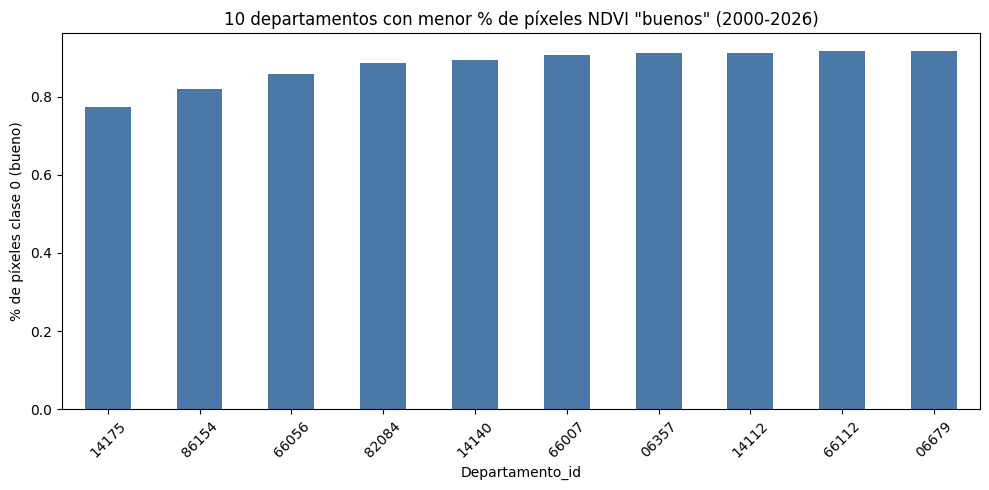

In [22]:
calidad_por_depto = df_reliability.groupby('Departamento_id')[['pct_bueno', 'pct_marginal', 'pct_nublado']].mean()
peor_calidad = calidad_por_depto.sort_values('pct_bueno').head(10)
print(peor_calidad.round(3))

plt.figure(figsize=(10, 5))
peor_calidad['pct_bueno'].plot(kind='bar', color='#4C78A8')
plt.title('10 departamentos con menor % de píxeles NDVI "buenos" (2000-2026)')
plt.ylabel('% de píxeles clase 0 (bueno)')
plt.xlabel('Departamento_id')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


En promedio nacional (158 departamentos, 2000–2026, sin ponderar por superficie): **94,6% de los píxeles son "buenos"**, 3,0% marginales, 2,4% nublados, y prácticamente 0% nieve/hielo (la capa nunca reporta esa clase para estos departamentos, esperable en zonas agrícolas templadas/subtropicales sin nieve persistente). Es una señal de calidad alta en general — consistente con que el promedio simple de `Mean` en 3.2.8 (sin filtrar por reliability) no debería estar arrastrando mucho ruido de nubes o datos marginales.

El peor departamento es **Tulumba (Córdoba, id 14175)**, con 77,4% buenos / 10,5% marginales / 12,1% nublados — bastante por debajo del promedio nacional, pero todavía mayoritariamente confiable. Le siguen Rivadavia (Santiago del Estero), General José de San Martín (Salta) y Rosario (Santa Fe), todos con 82-89% de píxeles buenos. Ningún departamento del top-10 peor tiene una fracción de píxeles no confiables (marginal + nublado) que supere el 23%.

Esto confirma que mantener el promedio simple de `Mean` en 3.2.8, sin filtrar por confiabilidad de píxel, es una simplificación razonable para este dataset — no hay evidencia de que algún departamento tenga una fracción grande de datos de mala calidad que distorsione sistemáticamente su NDVI. Si en el futuro se decide sumar un filtro por reliability, Tulumba es el primer candidato donde revisar si cambia algo.


#### 3.2.11 Join: campañas + features climáticas + NDVI + ONI


In [23]:
df_final_campanias = pd.merge(df, df_resultados_pivot, on=['Cultivo', 'Departamento_id', 'Campaña'], how='left')
df_final_campanias = df_final_campanias.merge(
    df_resultados_ndvi_pivot, on=['Cultivo', 'Departamento_id', 'Campaña'], how='left'
)
df_final_campanias = df_final_campanias.merge(
    df_resultados_oni_pivot, on=['Cultivo', 'Departamento_id', 'Campaña'], how='left'
)

df_final_campanias = df_final_campanias.drop(columns=['cultivo_ventana'])

print(df_final_campanias.shape)
print(df_final_campanias.isnull().sum())


(18537, 33)
Cultivo                               0
Anio_Inicio                           0
Campaña                               0
Departamento                          0
Departamento_id                       0
Sembrado(Ha)                          0
Cosechado(Ha)                         0
Producción(MTn)                       0
Perdido(Ha)                           0
Rinde(qq/Ha)                          0
Zona                                  0
amplitud_termica_floracion            0
amplitud_termica_llenado              0
deficit_hidrico_extremo_floracion     0
deficit_hidrico_extremo_llenado       0
estres_termico_floracion              0
estres_termico_llenado                0
helada_agro_floracion                 0
helada_agro_llenado                   0
precipitacion_total_floracion         0
precipitacion_total_llenado           0
radiacion_solar_promedio_floracion    0
radiacion_solar_promedio_llenado      0
temperatura_media_floracion           0
temperatura_media_llenado   

Comprobamos que no haya valores nulos en ninguna columna, y que el join no haya inflado ni recortado filas: el dataset final tiene exactamente las mismas filas que `df` antes del merge — cada campaña×departamento×cultivo se cruzó una sola vez con sus features climáticas y de NDVI.


#### 3.2.12 Dataset final de rendimiento


Este es el dataset final que se usará para entrenar al modelo que va a predecir los valores de rinde en base a las variables climáticas y de NDVI que fuimos calculando.


In [24]:
df_final_campanias.head()


,Cultivo,Anio_Inicio,Campaña,Departamento,Departamento_id,Sembrado(Ha),Cosechado(Ha),Producción(MTn),Perdido(Ha),Rinde(qq/Ha),...,temperatura_media_floracion,temperatura_media_llenado,ndvi_n_observaciones_floracion,ndvi_n_observaciones_llenado,ndvi_promedio_floracion,ndvi_promedio_llenado,oni_promedio_floracion,oni_promedio_llenado,oni_categoria_floracion,oni_categoria_llenado
0,girasol,2000,2000/2001,Azul,06049,16000,15500,25500,500,16.45,...,20.481522,23.032273,4,3,0.588929,0.634144,-0.77,-0.650000,Niña,Niña
1,girasol,2000,2000/2001,San Cayetano,06742,50500,49500,54450,1000,11.00,...,20.585652,21.618864,4,3,0.413184,0.538748,-0.77,-0.576667,Niña,Niña
2,girasol,2000,2000/2001,Trenque Lauquen,06826,21000,19000,42000,2000,22.11,...,23.746304,24.459318,4,3,0.562463,0.609815,-0.77,-0.576667,Niña,Niña
3,girasol,2000,2000/2001,San Pedro,06770,800,800,1760,0,22.00,...,22.863043,24.023636,4,3,0.599223,0.709321,-0.77,-0.650000,Niña,Niña
4,girasol,2000,2000/2001,Salliqueló,06721,11300,11225,18500,75,16.48,...,24.677826,24.535227,4,3,0.530454,0.610670,-0.77,-0.576667,Niña,Niña


In [25]:
round(df_final_campanias.describe(), 2)


,Anio_Inicio,Sembrado(Ha),Cosechado(Ha),Producción(MTn),Perdido(Ha),Rinde(qq/Ha),amplitud_termica_floracion,amplitud_termica_llenado,deficit_hidrico_extremo_floracion,deficit_hidrico_extremo_llenado,...,radiacion_solar_promedio_floracion,radiacion_solar_promedio_llenado,temperatura_media_floracion,temperatura_media_llenado,ndvi_n_observaciones_floracion,ndvi_n_observaciones_llenado,ndvi_promedio_floracion,ndvi_promedio_llenado,oni_promedio_floracion,oni_promedio_llenado
count,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,...,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00,18537.00
mean,2012.26,39072.87,36478.70,123997.95,2594.17,31.90,14.46,13.58,8.90,10.53,...,24.67,21.38,23.27,22.22,2.43,3.62,0.58,0.64,0.01,0.01
std,7.18,58278.77,56412.07,225551.79,7107.57,20.22,1.88,1.67,4.14,4.03,...,3.49,2.63,4.27,2.66,0.84,0.75,0.11,0.11,0.98,0.84
min,2000.00,10.00,10.00,19.00,-7130.00,0.28,3.85,5.30,2.00,3.00,...,13.08,12.25,9.18,14.37,1.00,2.00,0.22,0.22,-1.76,-1.68
25%,2006.00,8000.00,7000.00,15930.00,0.00,19.00,13.28,12.49,6.00,8.00,...,22.41,19.65,21.88,20.36,2.00,3.00,0.51,0.57,-0.76,-0.64
50%,2012.00,20800.00,18575.00,51250.00,150.00,25.50,14.73,13.64,8.00,10.00,...,25.75,21.42,24.10,22.19,2.00,4.00,0.60,0.66,-0.22,-0.12
75%,2019.00,46000.00,42400.00,138000.00,1950.00,37.63,15.81,14.76,11.00,12.00,...,27.31,23.24,25.99,24.00,3.00,4.00,0.66,0.71,0.71,0.62
max,2024.00,859273.00,850273.00,3412500.00,137030.00,118.00,19.61,18.46,31.00,38.00,...,31.26,29.20,33.16,31.54,4.00,5.00,0.87,0.87,2.54,2.44


In [26]:
columnas = df_final_campanias.columns.to_list()
for col in columnas:
    print(f"Columna: {col} | Tipo de dato: {df_final_campanias[col].dtypes}")


Columna: Cultivo | Tipo de dato: object
Columna: Anio_Inicio | Tipo de dato: int64
Columna: Campaña | Tipo de dato: object
Columna: Departamento | Tipo de dato: object
Columna: Departamento_id | Tipo de dato: object
Columna: Sembrado(Ha) | Tipo de dato: int64
Columna: Cosechado(Ha) | Tipo de dato: int64
Columna: Producción(MTn) | Tipo de dato: int64
Columna: Perdido(Ha) | Tipo de dato: int64
Columna: Rinde(qq/Ha) | Tipo de dato: float64
Columna: Zona | Tipo de dato: object
Columna: amplitud_termica_floracion | Tipo de dato: float64
Columna: amplitud_termica_llenado | Tipo de dato: float64
Columna: deficit_hidrico_extremo_floracion | Tipo de dato: int64
Columna: deficit_hidrico_extremo_llenado | Tipo de dato: int64
Columna: estres_termico_floracion | Tipo de dato: int64
Columna: estres_termico_llenado | Tipo de dato: int64
Columna: helada_agro_floracion | Tipo de dato: int64
Columna: helada_agro_llenado | Tipo de dato: int64
Columna: precipitacion_total_floracion | Tipo de dato: float64

**Interpretación de las columnas de `df_final_campanias`**

La tabla final reúne información agronómica, climática y de NDVI por cada combinación de cultivo, departamento y campaña. Cada fila representa una observación de un cultivo en un departamento durante una campaña específica.

1) **Identificadores de la observación**: `Cultivo` (Girasol, Maíz, Maní, Soja 1ra, Soja 2da o Trigo total), `Departamento` / `Departamento_id`, `Zona` (zona PAS o zona Maní usada para resolver la ventana fenológica — ver 3.2.6, no es una unidad geográfica propia del modelo), `Campaña`, `Anio_Inicio`.
2) **Variables de superficie y producción**: `Sembrado(Ha)`, `Perdido(Ha)` (derivada), `Cosechado(Ha)`, `Rinde(qq/Ha)` (target del modelo), `Producción(MTn)`.
3) **Variables climáticas por etapa** (`_floracion` / `_llenado`): `precipitacion_total`, `temperatura_media`, `radiacion_solar_promedio`, `amplitud_termica`, `deficit_hidrico_extremo`, `estres_termico`, `helada_agro`.
4) **Variables de NDVI por etapa**: `ndvi_promedio`, `ndvi_n_observaciones` (composiciones MODIS de 16 días promediadas en la ventana — entre 1 y 5 según la duración de la etapa).
5) **Variable de ENSO (Índice ONI) por etapa**: `oni_promedio_floracion`, `oni_promedio_llenado` (ver 3.2.9) — anomalía ONI histórica promedio durante cada etapa fenológica, no depende del departamento (es un índice oceánico global), sólo de las fechas de la ventana. `oni_categoria_floracion`/`oni_categoria_llenado` son la versión discretizada del mismo valor (`'Niño'`/`'Niña'`/`'Neutral'`, umbral ±0.5°C de NOAA CPC), pensada para reducir la cardinalidad efectiva por campaña (ver notebook 05, sección 5.9.3).

A diferencia del dataset de 15 zonas, acá la unidad de análisis es el departamento, no la zona: dos departamentos de la misma `Zona` PAS comparten la ventana fenológica (mismas fechas de floración/llenado), pero cada uno tiene su propia serie climática y de NDVI, porque el clima se descargó por departamento (endpoint `/point` sobre el centroide), no promediado por zona.

In [27]:
df_final_campanias.to_csv('../data/processed/dataset_modelo_rendimiento.csv', index=False)


In [28]:
print('filas antes:', len(df), '| filas después de mergear clima y NDVI:', len(df_final_campanias))
print()
print('nulos por columna:')
print(df_final_campanias.isna().sum())


filas antes: 18537 | filas después de mergear clima y NDVI: 18537

nulos por columna:
Cultivo                               0
Anio_Inicio                           0
Campaña                               0
Departamento                          0
Departamento_id                       0
Sembrado(Ha)                          0
Cosechado(Ha)                         0
Producción(MTn)                       0
Perdido(Ha)                           0
Rinde(qq/Ha)                          0
Zona                                  0
amplitud_termica_floracion            0
amplitud_termica_llenado              0
deficit_hidrico_extremo_floracion     0
deficit_hidrico_extremo_llenado       0
estres_termico_floracion              0
estres_termico_llenado                0
helada_agro_floracion                 0
helada_agro_llenado                   0
precipitacion_total_floracion         0
precipitacion_total_llenado           0
radiacion_solar_promedio_floracion    0
radiacion_solar_promedio_llenado  

Guardamos el dataset en la carpeta `processed` para usarlo en la etapa siguiente.


### 3.3 Track A — Precio

En esta sección preparamos el dataset para entrenar los modelos que van a predecir los valores de los cultivos a 30/60/90 días.

#### 3.3.1 Resample semanal de la serie de precios

En el Track A se aplicó resample porque la serie de precios original estaba en una frecuencia diaria y no siempre resultaba homogénea ni comparable con el resto de los datos analizados. Al convertir la serie a una periodicidad semanal con resample('W'), se estandariza el horizonte temporal y se reduce el ruido de la variación diaria, manteniendo la tendencia general del precio.

Además, se utilizó mean() para resumir cada semana con un valor representativo y ffill() para completar vacíos temporales. Esto permite conservar la continuidad de la serie y preparar una base semanal más estable para el análisis de precios, sin perder la progresión histórica del indicador.

In [29]:
dfs = {'Precios_girasol':df_precios_girasol, 
       'Precios_maiz':df_precios_maiz, 
       'Precios_soja':df_precios_soja, 
       'Precios_trigo':df_precios_trigo}

In [30]:
for name, df in dfs.items():
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    df.set_index('Fecha', inplace=True)
    df = df['Precio en USD'].dropna()
    df = df.resample('W').mean().ffill()
    dfs[name] = df

#### 3.3.2 Verificación de la serie final

In [31]:
for name, df in dfs.items():
    print(f"DataFrame {name}:")
    print(df.head())

DataFrame Precios_girasol:
Fecha
2002-01-13    178.571429
2002-01-20    152.779627
2002-01-27    135.135135
2002-02-03    127.944813
2002-02-10    127.944813
Freq: W-SUN, Name: Precio en USD, dtype: float64
DataFrame Precios_maiz:
Fecha
2002-01-13    82.142857
2002-01-20    70.278628
2002-01-27    62.432432
2002-02-03    59.366393
2002-02-10    59.366393
Freq: W-SUN, Name: Precio en USD, dtype: float64
DataFrame Precios_soja:
Fecha
2002-01-13    164.285714
2002-01-20    140.557257
2002-01-27    125.340541
2002-02-03    120.063413
2002-02-10    120.063413
Freq: W-SUN, Name: Precio en USD, dtype: float64
DataFrame Precios_trigo:
Fecha
2002-01-13    95.142857
2002-01-20    81.400985
2002-01-27    73.124324
2002-02-03    70.472003
2002-02-10    70.472003
Freq: W-SUN, Name: Precio en USD, dtype: float64


Comprobamos que todos los datasets se guardaron correctamente.

#### 3.3.3 Dataset final de precio

In [32]:
for name, df in dfs.items():
    df.to_csv(f'../data/processed/{name}_semanal.csv')

Guardamos los datasets procesados asignandole '_semanal' al final para distinguirlo y saber cuál usar en el siguiente notebook para entrenar los modelos.

In [33]:
for name, df in dfs.items():
    print(f"{name}: {len(df)} semanas | {df.index.min()} → {df.index.max()}")

Precios_girasol: 1285 semanas | 2002-01-13 00:00:00 → 2026-08-23 00:00:00
Precios_maiz: 1285 semanas | 2002-01-13 00:00:00 → 2026-08-23 00:00:00
Precios_soja: 1285 semanas | 2002-01-13 00:00:00 → 2026-08-23 00:00:00
Precios_trigo: 1285 semanas | 2002-01-13 00:00:00 → 2026-08-23 00:00:00


Observamos que los datasets resultantes tienen información que abarca 1285 semanas, iniciando el 13 de enero de 2002 y terminando el 23 de agosto de 2026.


### 3.4 Exportación a data/processed/

La Sección 3.4 guarda las bases ya preparadas para reutilizarse en los siguientes pasos del proyecto. Esta exportación permite conservar una versión consistente de los datos, evitando repetir procesos de limpieza, transformación y normalización cada vez que se trabaja con la información.

Los archivos generados en esta etapa son los siguientes:

| Archivo | Descripción |
|---|---|
| `dataset_modelo_rendimiento.csv` | Dataset final de rendimiento con variables agronómicas, climáticas y de NDVI por campaña, departamento y cultivo (158 departamentos, 6 cultivos). |
| `df.csv` | Base general ya procesada y consolidada. |
| `df_clima_filtrado.csv` | Datos climáticos filtrados y preparados para el análisis. |
| `df_crops_filtrados.csv` | Dataset de cultivos filtrado y normalizado. |
| `df_dolard.csv` | Serie del tipo de cambio del dólar usada como contexto macroeconómico. |
| `Precios_girasol_semanal.csv` | Serie semanal de precios de girasol. |
| `precios_girasol_usd.csv` | Datos de precios de girasol en USD. |
| `Precios_maiz_semanal.csv` | Serie semanal de precios de maíz. |
| `precios_maiz_usd.csv` | Datos de precios de maíz en USD. |
| `Precios_soja_semanal.csv` | Serie semanal de precios de soja. |
| `precios_soja_usd.csv` | Datos de precios de soja en USD. |
| `Precios_trigo_semanal.csv` | Serie semanal de precios de trigo. |
| `precios_trigo_usd.csv` | Datos de precios de trigo en USD. |